# Generalized Dispersion Mode Decomposition (GDMD)

This notebook walks through the theory and numerical examples from:

> Chen S., Wang K., Peng Z., Chang C., Zhai W.  
> *Generalized dispersive mode decomposition: Algorithm and applications.*  
> Journal of Sound and Vibration, 492:115800, 2021.  
> https://doi.org/10.1016/j.jsv.2020.115800


**Dispersive signals** (guided / Lamb waves, underwater acoustics, biomedical echoes, …)
have **frequency-dependent** travel times.  Their key descriptor is the **group delay (GD)**

$$
\tau(f)=\frac{1}{2\pi}\frac{\mathrm{d}}{\mathrm{d}f}\arg S(f),
$$

i.e. the derivative of the spectral phase w.r.t. frequency — the dual of the
instantaneous frequency (IF) of a chirp.

Practical dispersive records are often **multimodal** and their GD curves
(**dispersion curves**) may **cross** in the time–frequency (TF) plane.
Classical tools struggle here:

| Family | Limitation for dispersive / crossed modes |
|---|---|
| STFT / CWT / quadratic TF | Poor concentration or cross-terms |
| Synchrosqueezing (SST) and variants | Hard to resolve **close / crossed** ridges; sensitive to noise |
| EMD / EWT / VMD | Narrowband assumptions → over-split wideband modes |
| VNCMD / ACMD | Excellent for **chirps (IF)**, not for **dispersion (GD)** |
| Dispersion compensation (DCM) | Needs known GD; weak at TF **intersections** |

**GDMD** addresses this by (i) defining a non-parametric **generalized dispersive
mode (GDM)** in the frequency domain, and (ii) solving a joint variational problem
that simultaneously estimates all GDs and separates the modes — essentially an
**optimal dispersion compensation** procedure, dual to ACMD.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import GDMD
from pysdkit._gdmd import (
    make_dispersive_signal,
    curve_smooth,
    spectrum_to_time,
    tf_spec_from_gd,
)
from pysdkit.plot import plot_IMFs

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print(GDMD())

Generalized Dispersion Mode Decomposition (GDMD)


## 2. Signal model — Generalized Dispersive Mode (GDM)

### 2.1 Frequency-domain definition (paper Def. 1 / Eq. 5)

A real signal $s(t)$ is a GDM if its Fourier transform admits

$$
S(f)=A(f)\,\exp\!\left\{
-j\left[
2\pi\int_{0}^{f}\tau(\lambda)\,\mathrm{d}\lambda+\varphi
\right]
\right\},
$$

where

- $A(f)>0$ — slowly varying spectral amplitude,
- $\tau(f)>0$ — **group delay** (dispersion curve),
- $\varphi$ — constant phase.

The leading minus sign encodes a **time delay**.  Mild regularity conditions
($A,\tau\in C^1$, bounded derivatives) keep $A$ and $\tau$ slowly varying in $f$.

A noisy multimodal observation is then (Eq. 6)

$$
S(f)=\sum_{i=1}^{M}S_i(f)+\eta(f)
=\sum_{i=1}^{M}
A_i(f)\,\exp\!\left\{
-j\left[
2\pi\int_{0}^{f}\tau_i(\lambda)\,\mathrm{d}\lambda+\varphi_i
\right]
\right\}+\eta(f).
$$

### 2.2 Duality with chirps / ACMD

| | Chirp model (time) | GDM (frequency) |
|---|---|---|
| Carrier feature | Instantaneous frequency $f(t)$ | Group delay $\tau(f)$ |
| Demodulation | Frequency demodulation → baseband $c(t),d(t)$ | Dispersion compensation → $G_i(f)$ |
| Decomposition | ACMD / VNCMD | **GDMD** |
| Typical TF shape | Curves roughly parallel to time | Curves roughly parallel to frequency (impulses) or slanted (dispersion) |

Introducing compensation GDs $\bar\tau_i(f)$ yields (Eqs. 7–8)

$$
S(f)=\sum_{i=1}^{M}
G_i(f)\,\exp\!\left[-j2\pi\int_{0}^{f}\bar\tau_i(\lambda)\,\mathrm{d}\lambda\right]+\eta(f),
$$

$$
G_i(f)=A_i(f)\,
\exp\!\left\{
-j\left[
2\pi\int_{0}^{f}\bigl(\tau_i(\lambda)-\bar\tau_i(\lambda)\bigr)\,\mathrm{d}\lambda
+\varphi_i
\right]
\right\}.
$$

When $\bar\tau_i=\tau_i$, the residual phase vanishes and $G_i(f)$ becomes a
**short-duration impulse** at $\tau=0$ — that is classical **dispersion compensation**.


## 3. Variational formulation and iterative solver

### 3.1 Optimal dispersion compensation (Eq. 9)

GDMD estimates $\{G_i\}$ and $\{\bar\tau_i\}$ jointly by minimizing

$$
\min_{\{G_i\},\{\bar\tau_i\}}
\left\{
\sum_{i=1}^{M}\bigl\|G_i''(f)\bigr\|_2^2
+\alpha\left\|
S(f)-\sum_{i=1}^{M}S_i(f)
\right\|_2^2
\right\},
\quad
S_i(f)=G_i(f)\,
\exp\!\left[-j2\pi\int_{0}^{f}\bar\tau_i(\lambda)\,\mathrm{d}\lambda\right].
$$

Interpretation (same spirit as ACMD):

- $\|G_i''\|_2^2$ measures **smoothness in $f$** ≡ **short duration in $t$** after compensation;
- the data-fidelity term forces the reconstructed modes to explain $S(f)$;
- **joint** estimation of all $M$ modes balances energy near **ridge intersections**
  (the main improvement over plain DCM).

### 3.2 Discrete matrix form (Eq. 10)

On frequency bins $f_0,\ldots,f_{N-1}$,

$$
\min_{\mathbf{g},\,\mathbf{K}}
\bigl\{\|\Psi\mathbf{g}\|_2^2+\alpha\|\mathbf{s}-\mathbf{K}\mathbf{g}\|_2^2\bigr\},
$$

- $\mathbf{s}$ — stacked unilateral spectrum samples,
- $\mathbf{g}=[\mathbf{g}_1^\top,\ldots,\mathbf{g}_M^\top]^\top$ — compensated spectra $G_i(f)$,
- $\mathbf{K}=[\mathbf{K}_1,\ldots,\mathbf{K}_M]$ with diagonal kernels
  $\mathbf{K}_i=\mathrm{diag}\bigl(e^{-j\theta_i(f)}\bigr)$,
  $\theta_i(f)=2\pi\int_0^f\bar\tau_i$,
- $\Psi=\mathrm{blkdiag}(\Lambda,\ldots,\Lambda)$ — second-order difference for each mode.

### 3.3 Alternating iteration (Eqs. 14–17)

At iteration $n$:

1. **Update compensated spectra** (closed form / linear solve)

$$
\mathbf{g}^{(n+1)}
=
\left[
\frac{1}{\alpha}\Psi^\top\Psi
+(\mathbf{K}^{(n)})^H\mathbf{K}^{(n)}
\right]^{-1}
(\mathbf{K}^{(n)})^H\mathbf{s}.
$$

2. **Recover modes**
   $\mathbf{s}_i^{(n+1)}=\mathbf{K}_i^{(n)}\mathbf{g}_i^{(n+1)}$
   (acts as a **frequency-varying filter**; smaller $\alpha$ → narrower bandwidth /
   smoother modes).

3. **Read GD error from phase** of $G_i$

$$
\Delta\tau_i^{(n+1)}(f)
=
-\frac{1}{2\pi}
\frac{\mathrm{d}}{\mathrm{d}f}
\mathrm{unwrap}\!\bigl(\angle G_i^{(n+1)}(f)\bigr).
$$

4. **Smooth and update GD** (low-pass via second-order difference)

$$
\boldsymbol{\tau}_i^{(n+1)}
=
\boldsymbol{\tau}_i^{(n)}
+
\left[\frac{1}{\upsilon}\Lambda^\top\Lambda+\mathbf{I}\right]^{-1}
\Delta\boldsymbol{\tau}_i^{(n+1)}.
$$

   Smaller $\upsilon$ → smoother GD.  In PySDKit this weight is named ``beta``
   (matching the MATLAB toolbox).

5. Rebuild $\mathbf{K}$ from the new GDs and repeat until the relative change of
   recovered spectra falls below ``tol`` (paper / MATLAB demos often use
   $10^{-8}$).

Time-domain waveforms follow by Hermitian completion + inverse FFT of each
unilateral $\tilde S_i(f)$.

### 3.4 TF image from GDMD (Eq. 18)

With $\tilde A_i(f)=|\tilde S_i(f)|$ and estimated GDs $\tilde\tau_i(f)$,

$$
\mathrm{TFD}(t,f)=\sum_{i=1}^{M}\tilde A_i(f)\,\delta\bigl[t-\tilde\tau_i(f)\bigr].
$$

This paints each mode’s energy **along its dispersion curve** and yields a sharp
multimodal TF map even when SST blurs transient / crossed energy.


## 4. Two practical workflows

The paper and MATLAB demos use two initialisation patterns (both in PySDKit):

1. **Joint multi-mode** (numerical Example 1)  
   Provide $M$ initial GD curves from TF ridges (SFFT + ridge tracking / RPRG),
   optionally smooth them, then run the joint solver once.

2. **Successive extraction** (impulse / wheel-fault style)  
   For nearly **constant** GDs: take the envelope peak of the residual as a
   constant initial GD, extract one mode, subtract in the frequency domain,
   repeat.  In code: set ``K`` and omit ``init_gd``.

Recommended factor ranges from the paper (Sec. 3.2):

$$
10^{-6}\le\alpha\le10^{-2},\qquad
10^{-8}\le\upsilon\le10^{-5}.
$$

Larger factors keep more detail / converge faster on rough inits, but admit more
noise and inter-mode leakage.


## 5. Example 1 — three crossed dispersive modes

Paper Eq. (20): three modes on $0\le f\le 50\,\mathrm{Hz}$ with **quadratic** GDs
that cross in the TF plane (`fs = 100` Hz, duration `T = 15` s).  This is the
canonical test that DCM fails near intersections while GDMD still separates
modes cleanly.


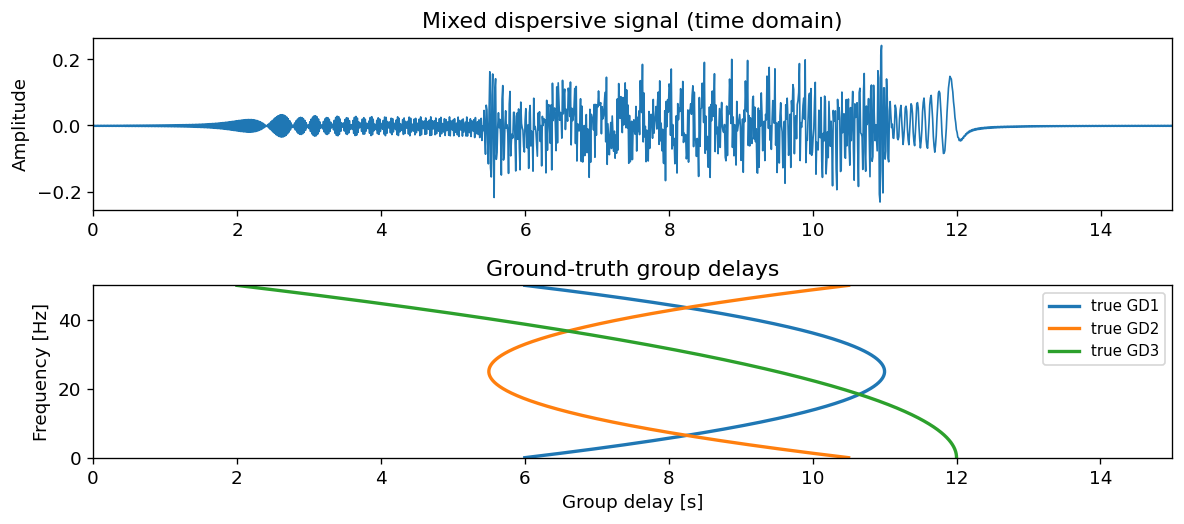

In [2]:
fs = 100.0
T = 15.0
t, signal, f, spectrum, true_gds, true_modes = make_dispersive_signal(
    samp_freq=fs, duration=T
)

fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=False)
axes[0].plot(t, signal, color="C0", lw=1.0)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Mixed dispersive signal (time domain)")
axes[0].set_xlim(t[0], t[-1])

for k, gd in enumerate(true_gds):
    axes[1].plot(gd, f, lw=2.0, label=f"true GD{k+1}")
axes[1].set_xlabel("Group delay [s]")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_title("Ground-truth group delays")
axes[1].set_xlim(0, T)
axes[1].set_ylim(0, fs / 2)
axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 5.1 Run the joint GDMD solver

In the full MATLAB pipeline, initial GDs come from SFFT ridges + ridge-path
regrouping (RPRG), then ``curvesmooth``.  Below we start from the **smoothed
ground-truth GDs** so the notebook focuses on the **solver** (Eqs. 14–17) and
its accuracy, matching Fig. 6–7 style diagnostics in the paper.


In [3]:
init_gd = curve_smooth(true_gds, beta=1e-7)

decomp = GDMD(alpha=1e-3, beta=1e-7, tol=1e-8, max_iter=300)
modes, est_gds, modes_freq = decomp.fit_transform(
    signal,
    fs=fs,
    init_gd=init_gd,
    return_all=True,
    smooth_init_beta=None,  # already smoothed above
)

recon = modes.sum(axis=0)
rel_err = np.linalg.norm(recon - signal) / np.linalg.norm(signal)
print(f"modes shape: {modes.shape}")
print(f"reconstruction relative error: {rel_err:.3e}")

for k in range(3):
    re_db = 20 * np.log10(
        np.linalg.norm(est_gds[k] - true_gds[k]) / (np.linalg.norm(true_gds[k]) + 1e-30)
    )
    corr = np.corrcoef(modes[k], true_modes[k])[0, 1]
    print(f"mode {k+1}: GD RE = {re_db:6.1f} dB, time-domain corr = {corr:.4f}")

modes shape: (3, 1500)
reconstruction relative error: 5.769e-03
mode 1: GD RE =  -62.8 dB, time-domain corr = 1.0000
mode 2: GD RE =  -60.8 dB, time-domain corr = 1.0000
mode 3: GD RE =  -67.7 dB, time-domain corr = 1.0000


### 5.2 Time-domain modes

Compare each recovered mode with the analytic ground truth (paper Fig. 7b style).
Reconstruction error should be small when GDs have converged.


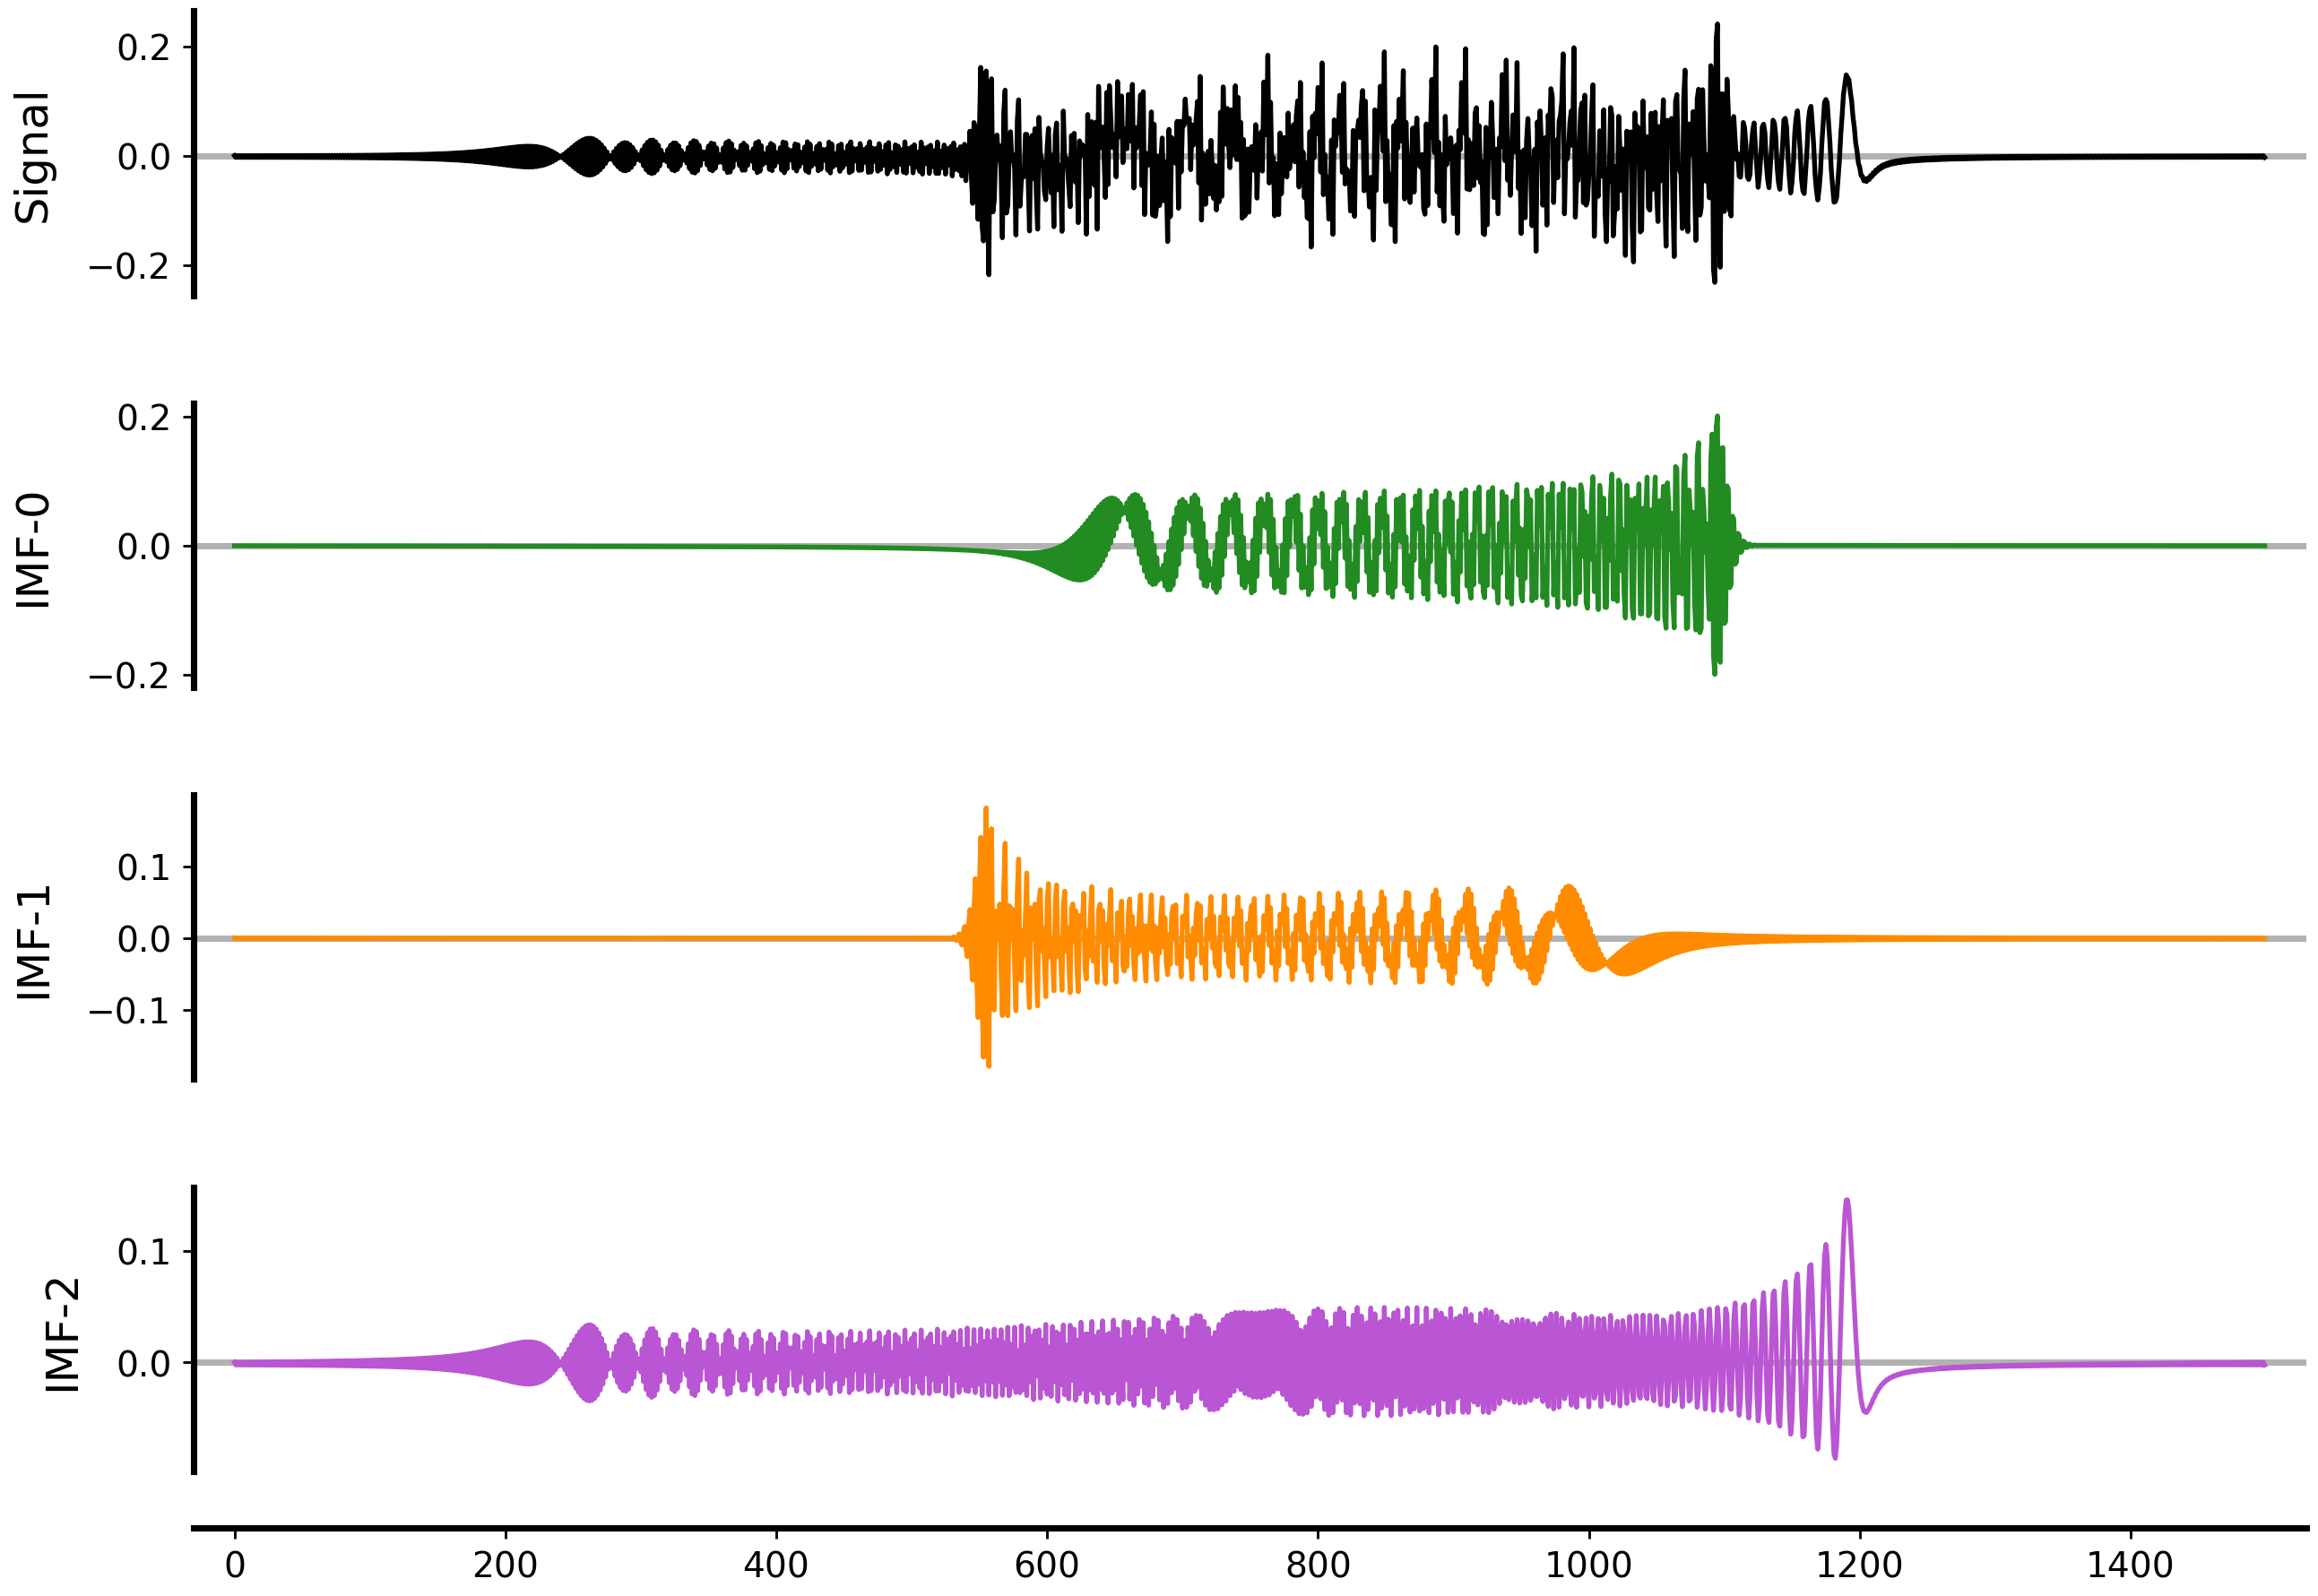

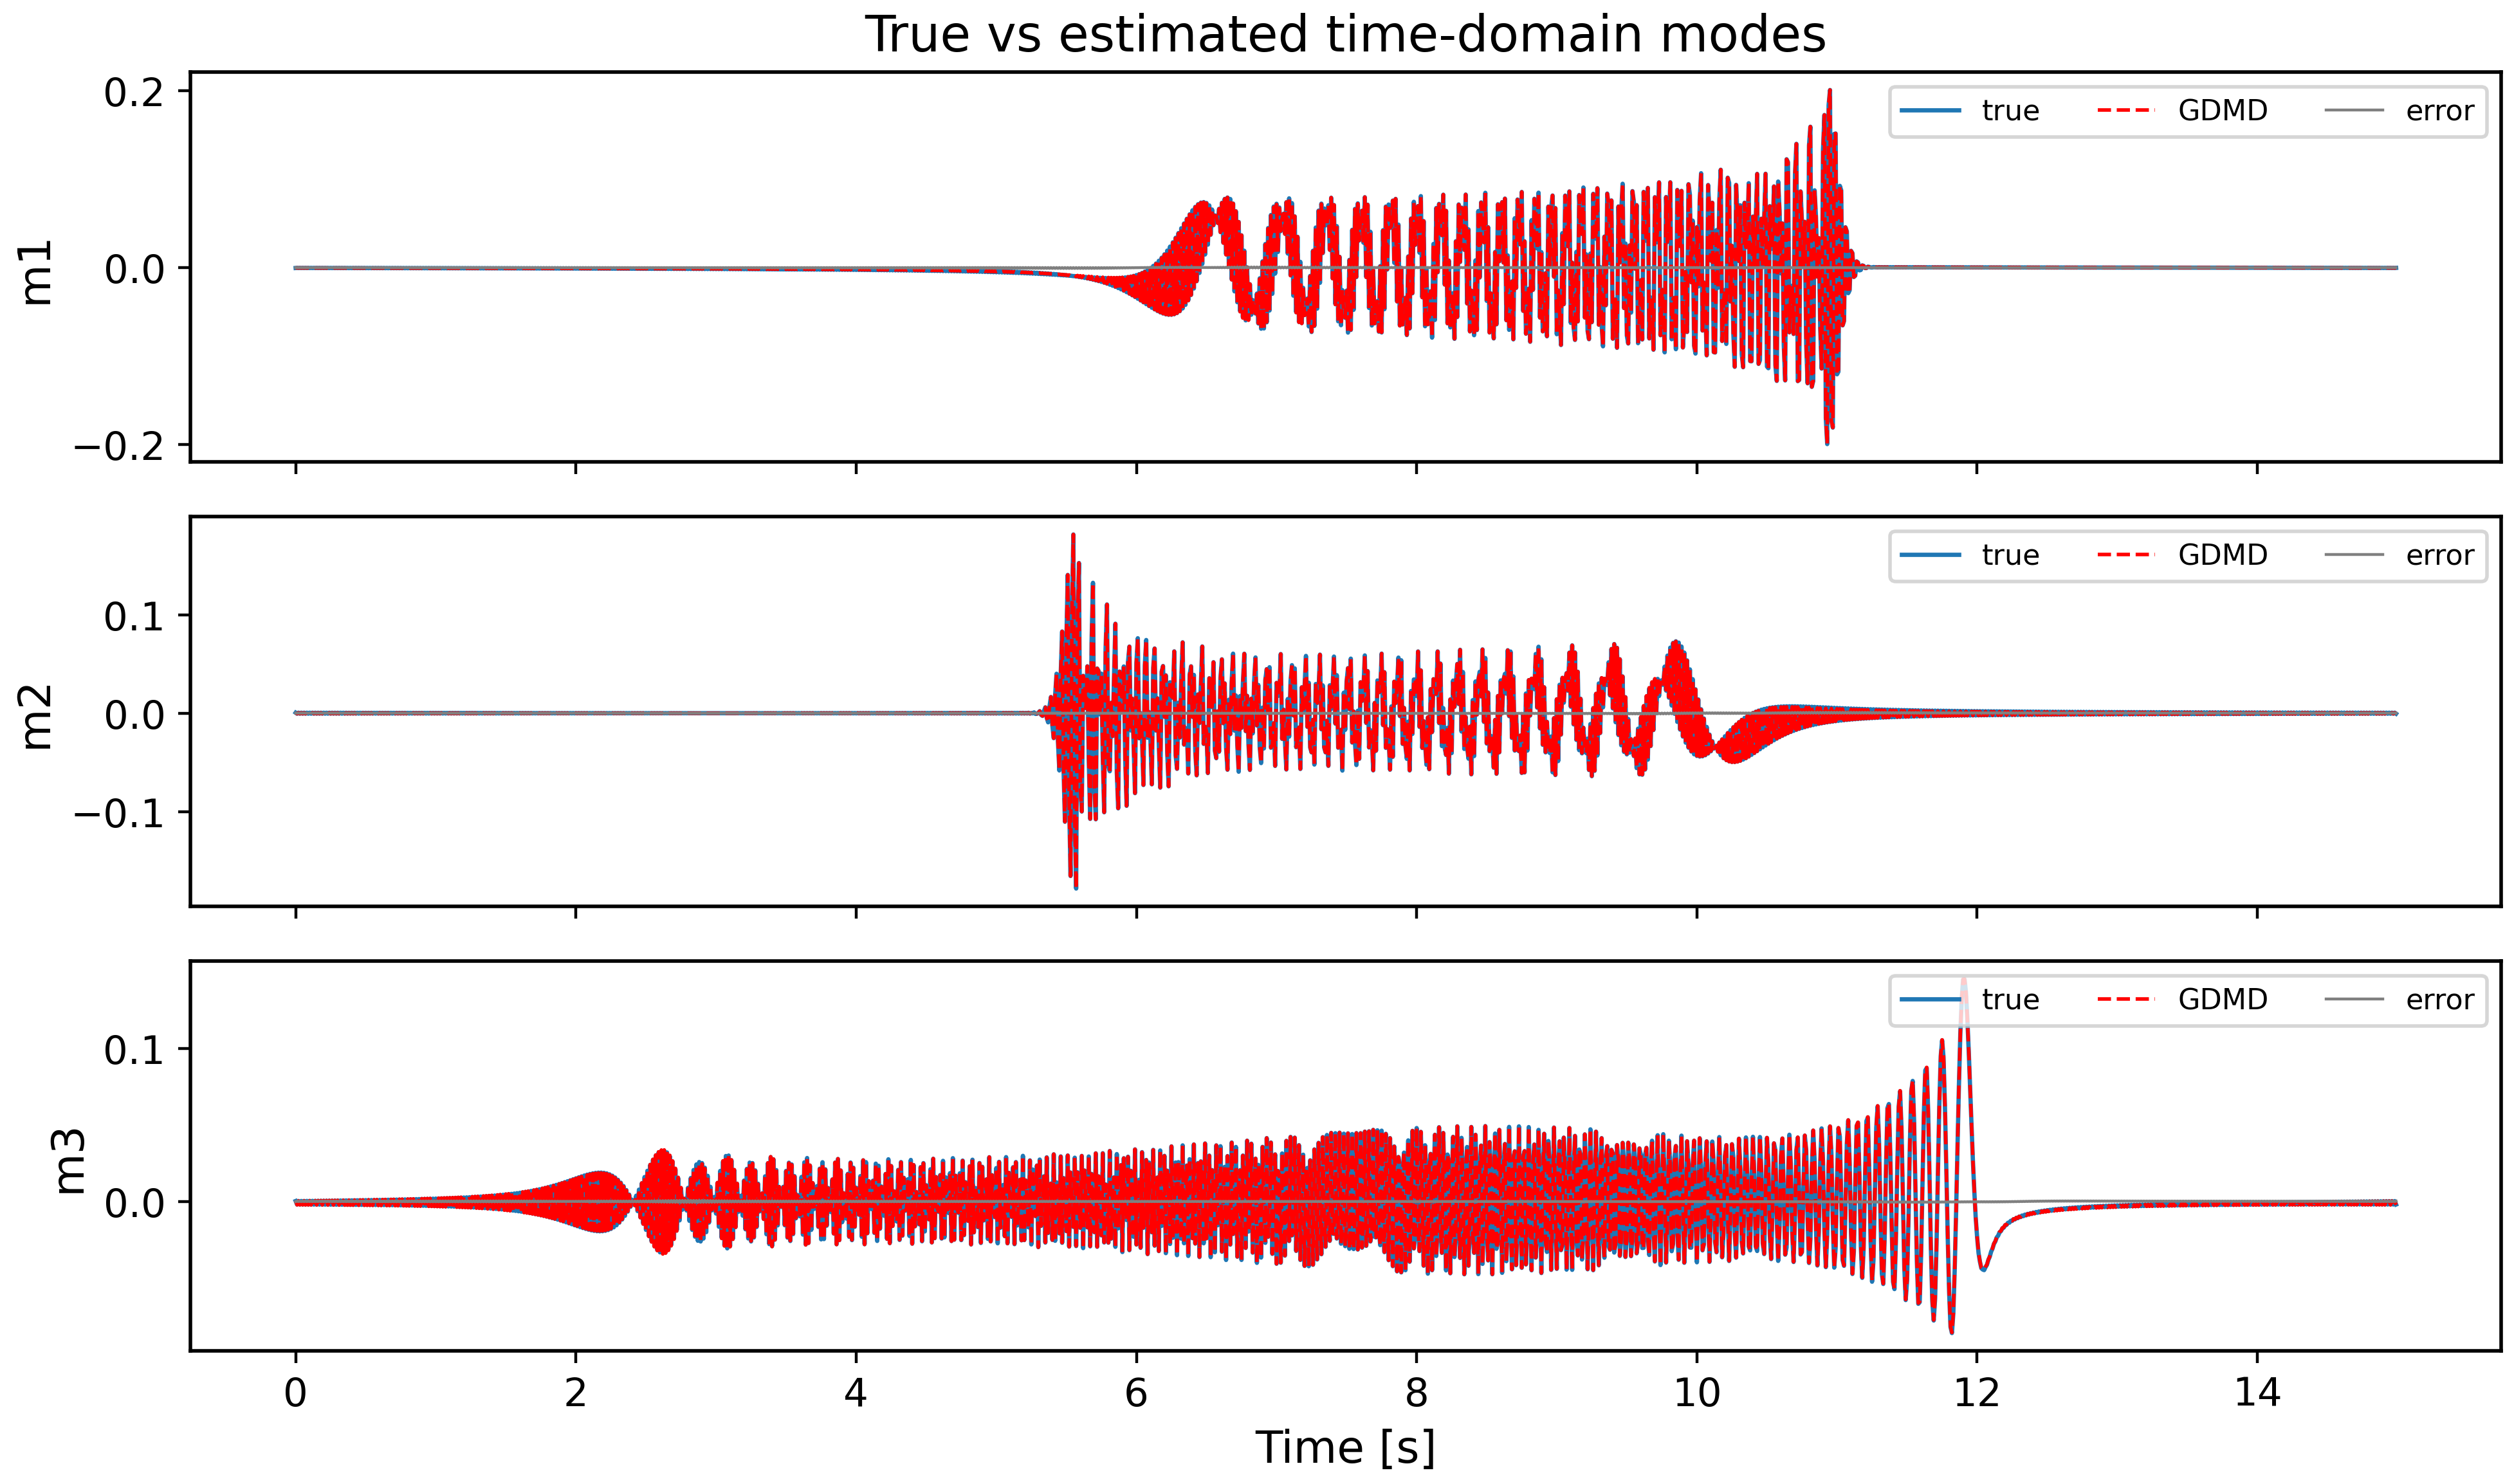

In [4]:
plot_IMFs(signal, modes, max_imfs=3)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for k in range(3):
    axes[k].plot(t, true_modes[k], color="C0", lw=1.2, label="true")
    axes[k].plot(t, modes[k], "r--", lw=1.0, label="GDMD")
    axes[k].plot(t, true_modes[k] - modes[k], color="0.5", lw=0.8, label="error")
    axes[k].set_ylabel(f"m{k+1}")
    axes[k].legend(loc="upper right", fontsize=8, ncol=3)
axes[-1].set_xlabel("Time [s]")
axes[0].set_title("True vs estimated time-domain modes")
plt.tight_layout()
plt.show()

### 5.3 Frequency-domain modes and estimated GDs

GDMD works on the **unilateral spectrum**.  The real part of each $\tilde S_i(f)$
and the GD curves $\tilde\tau_i(f)$ should align with the synthetic construction
(paper Fig. 7a and GD overlays).


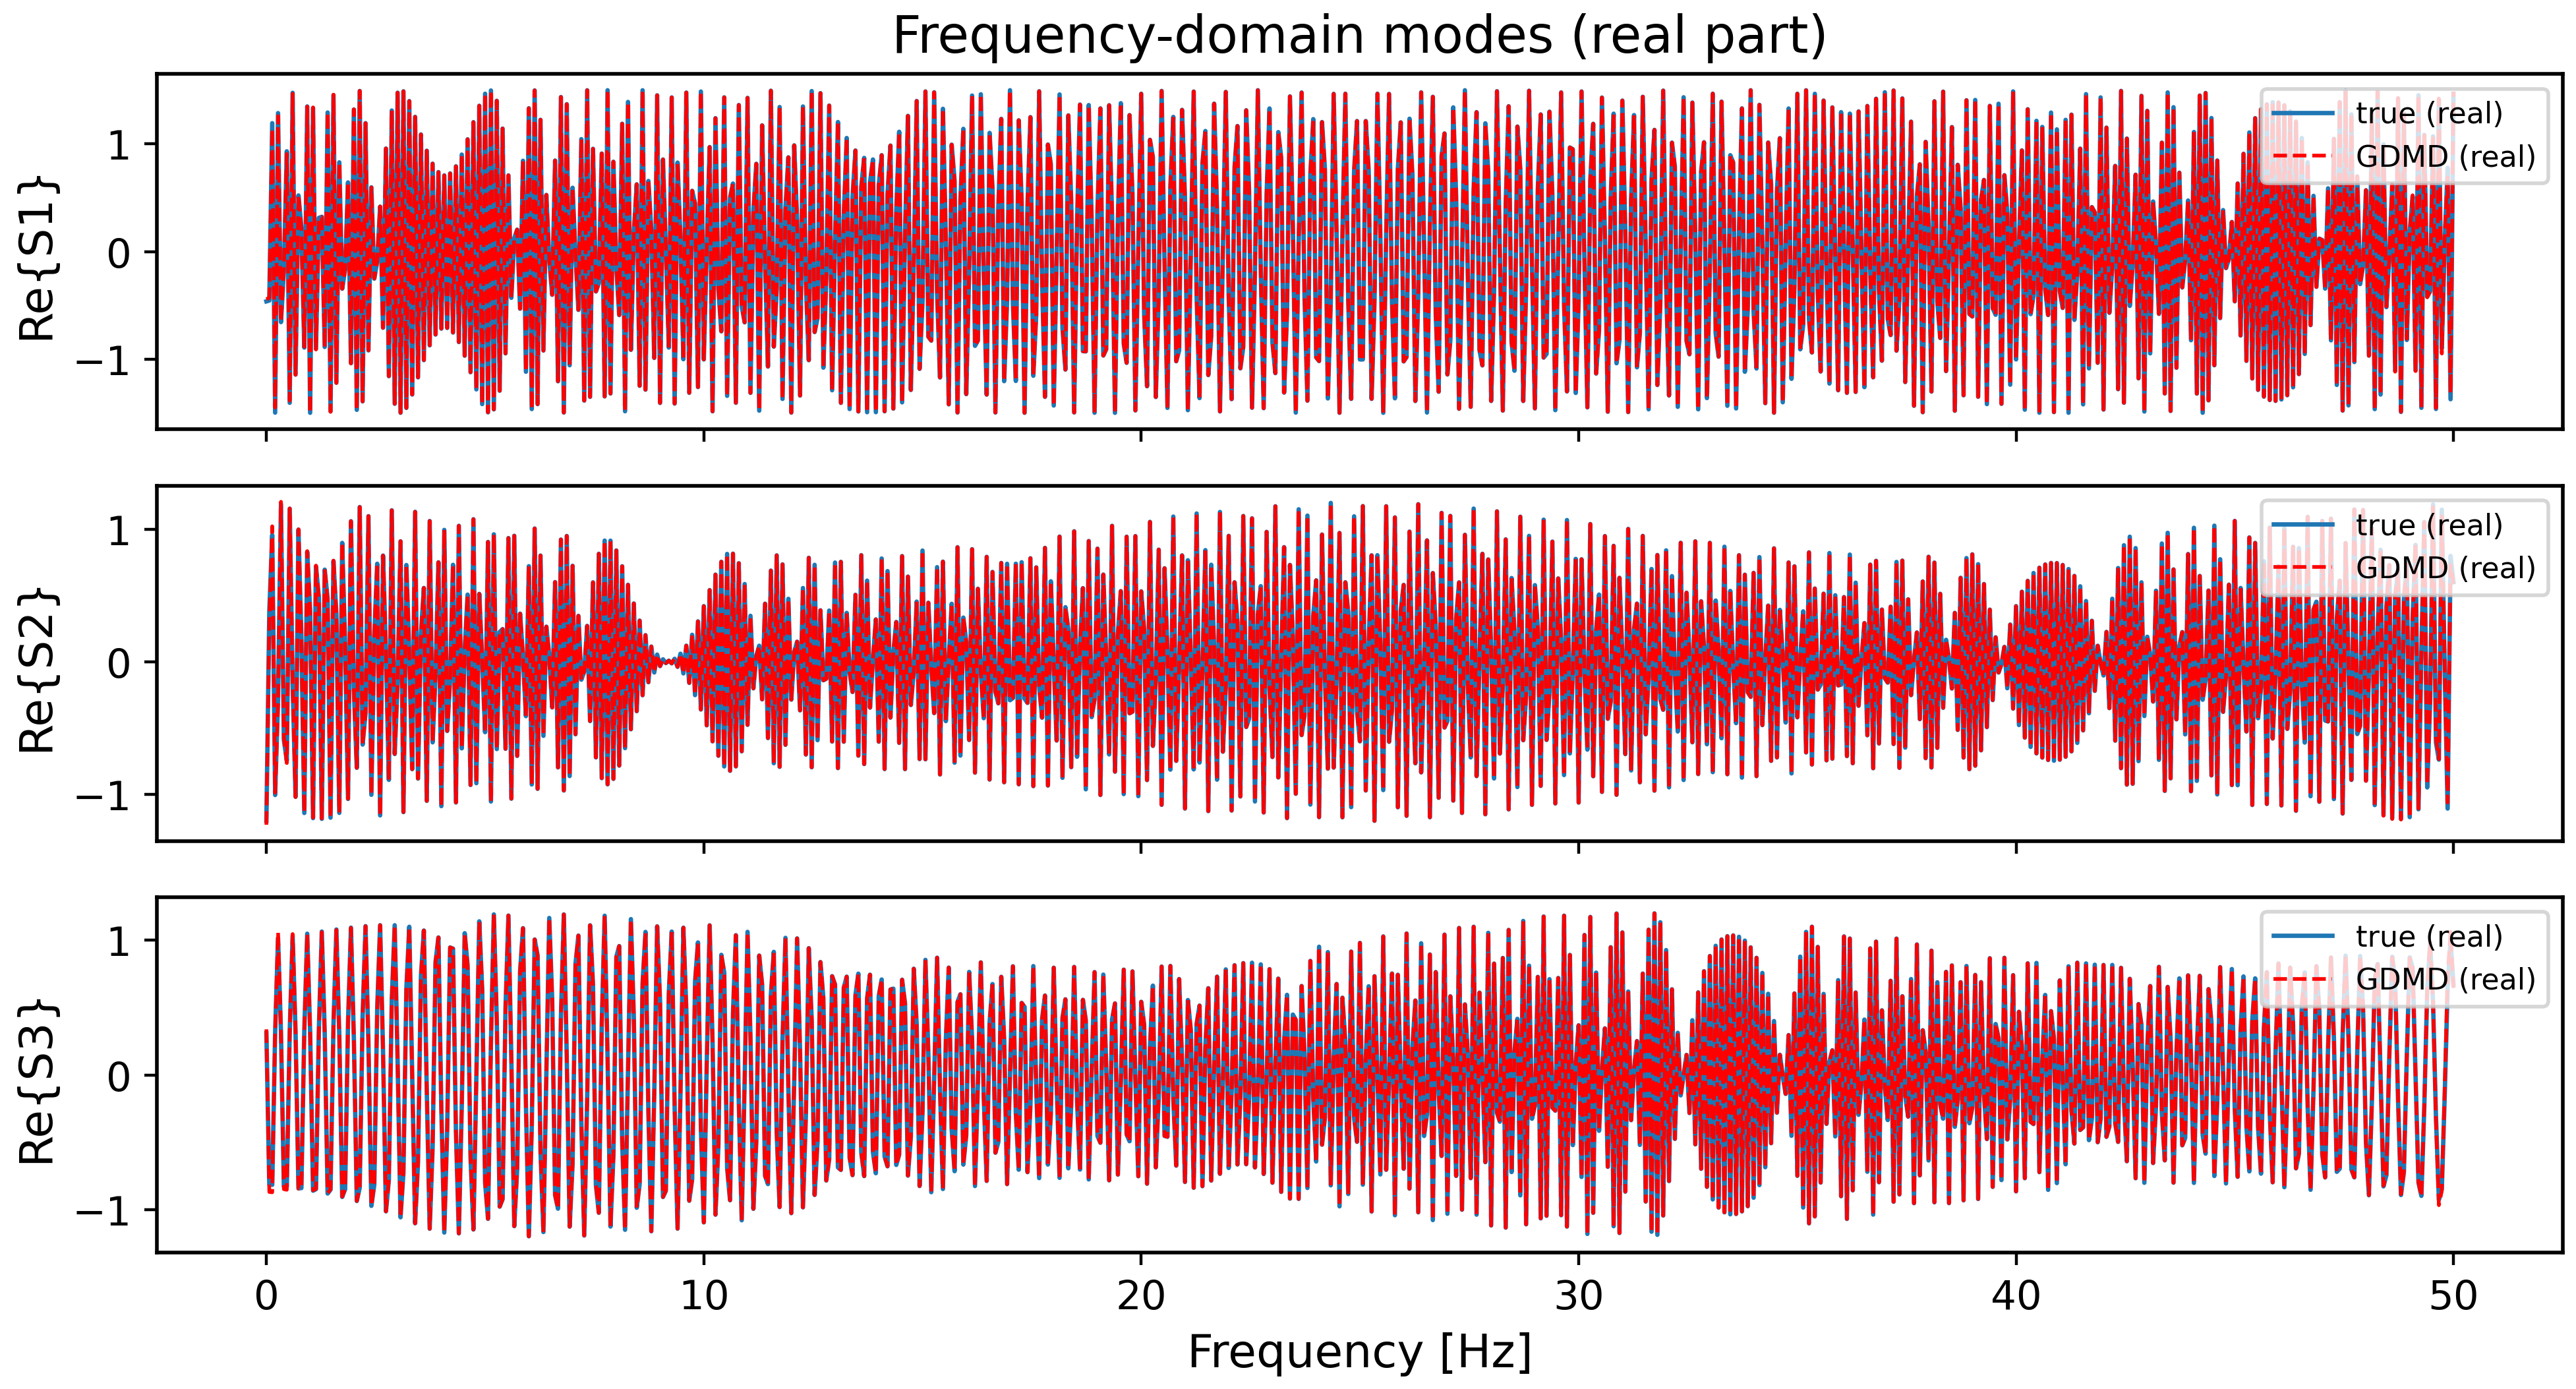

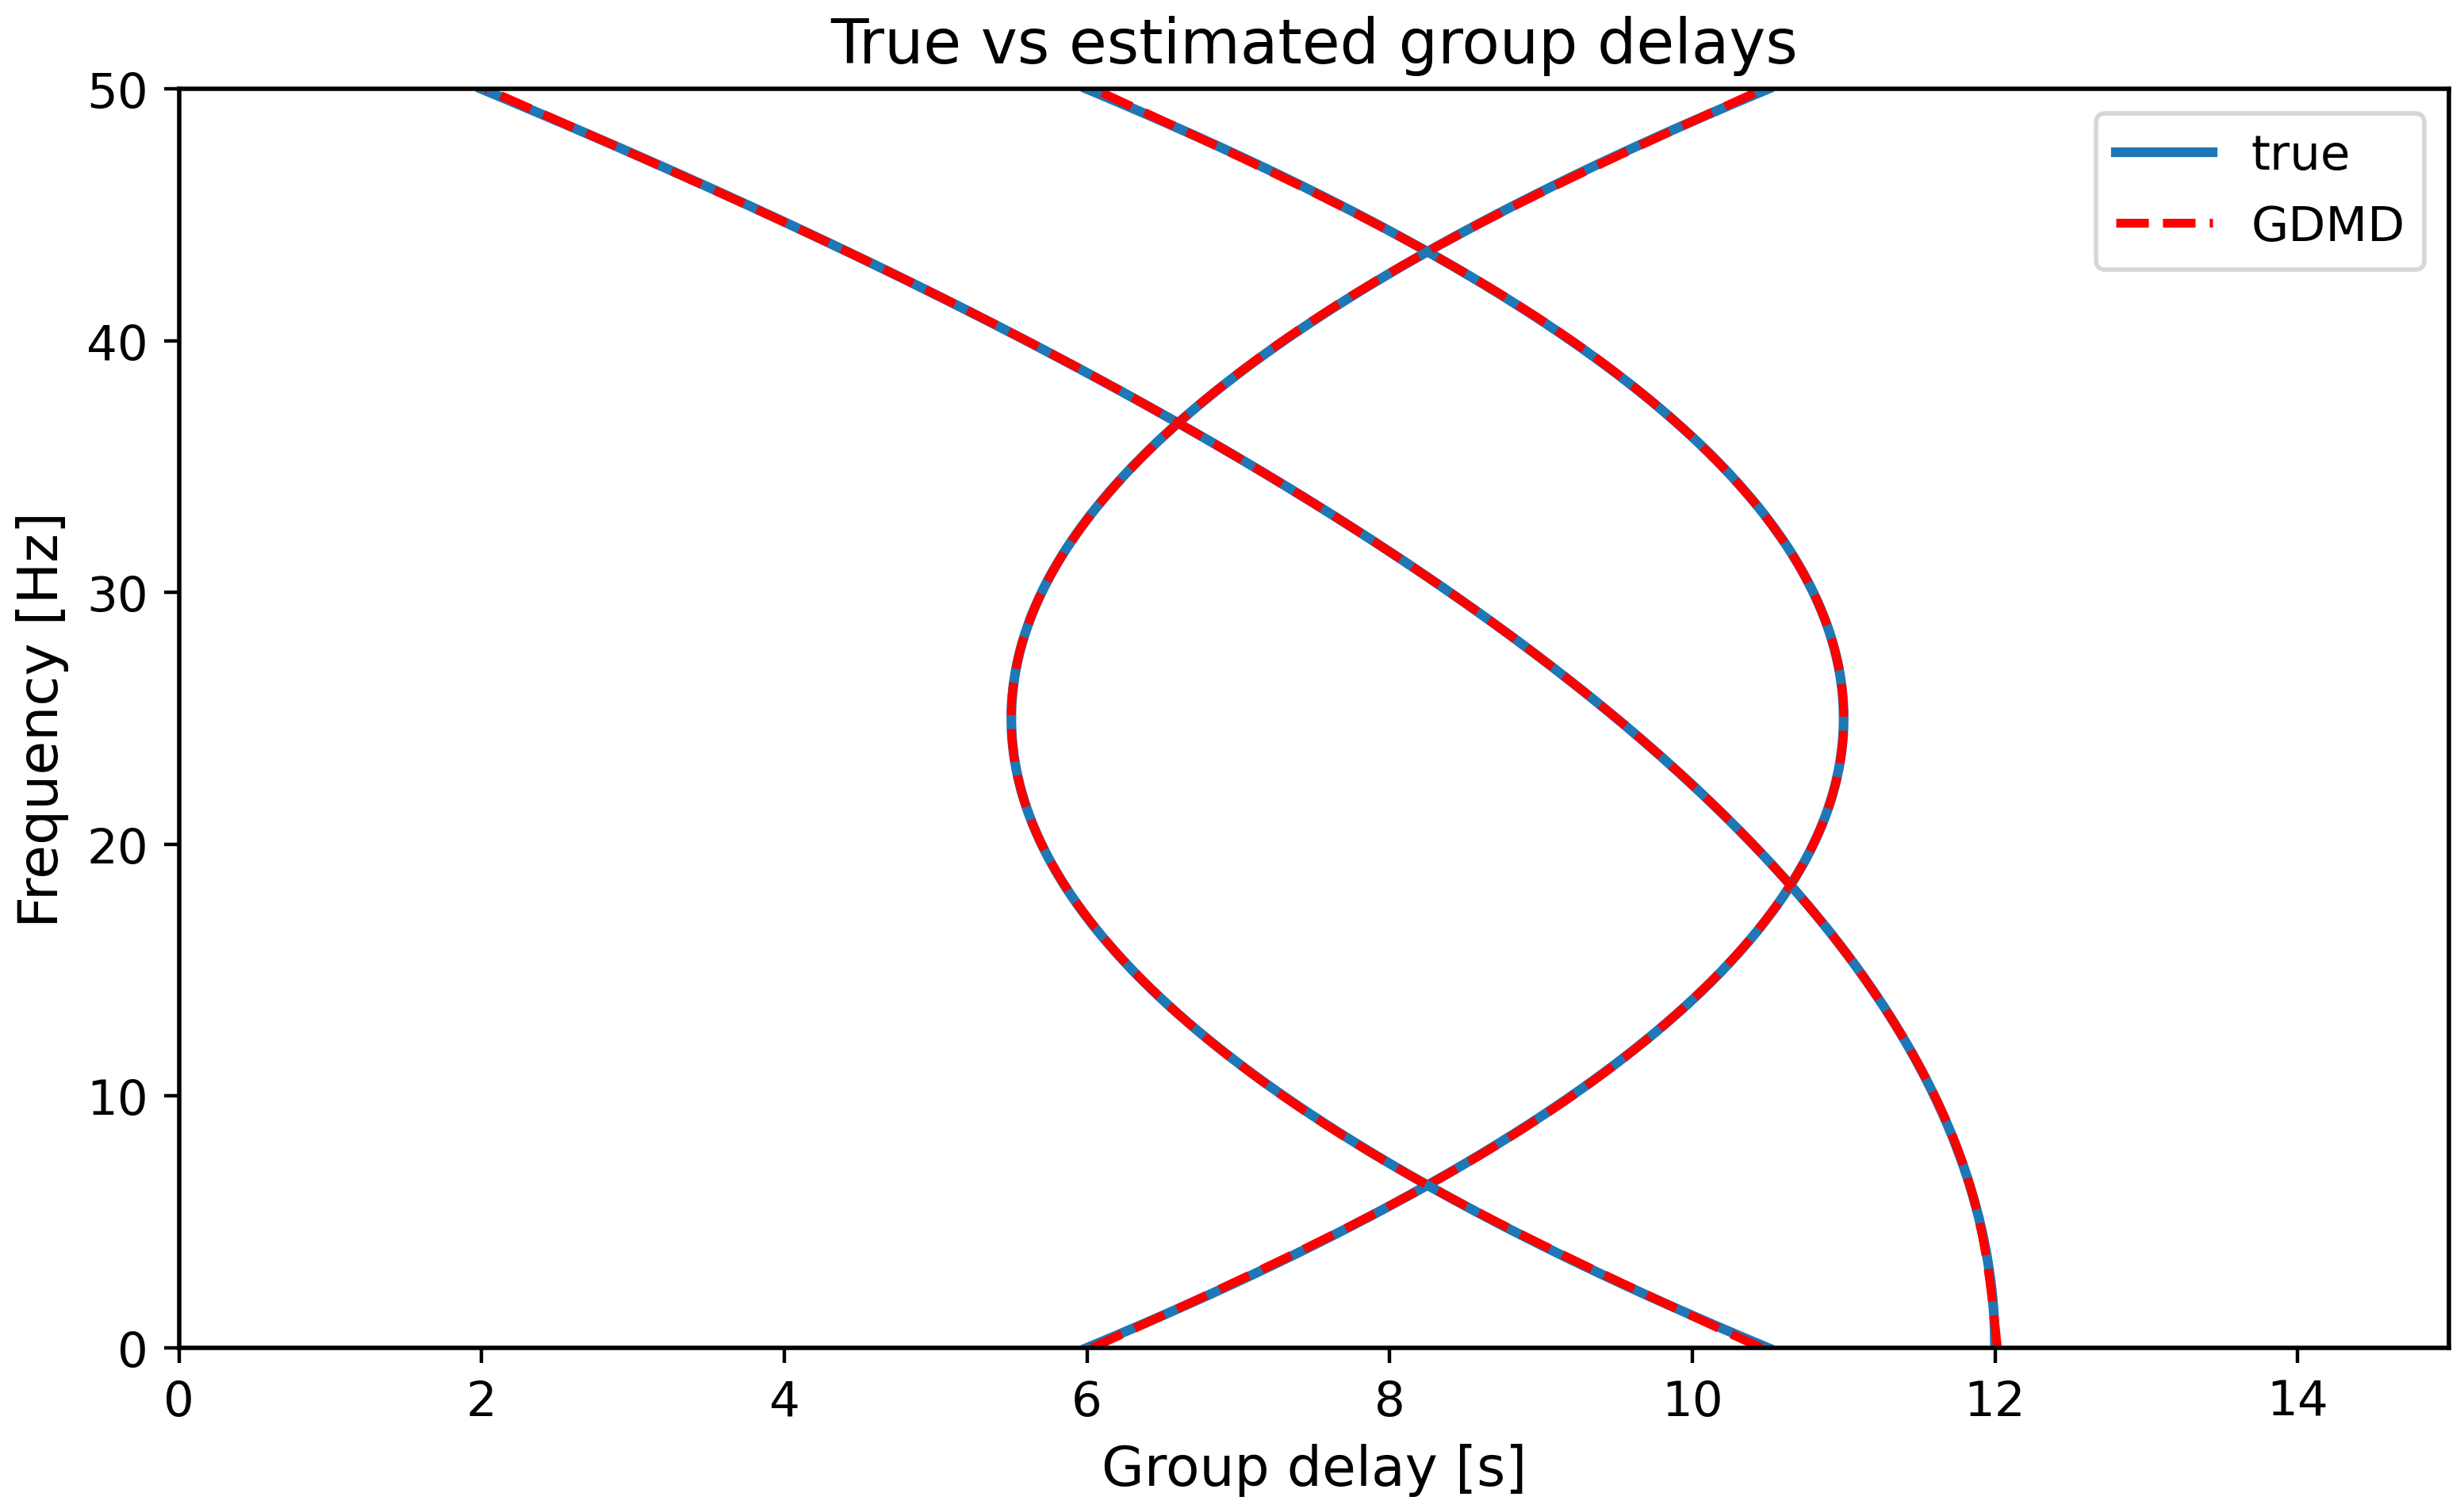

In [5]:
# Unilateral spectra of the ground-truth time modes (for visual comparison)
true_uni = np.vstack([np.fft.fft(tm)[: len(f)] for tm in true_modes])

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
for k in range(3):
    axes[k].plot(f, np.real(true_uni[k]), color="C0", lw=1.2, label="true (real)")
    axes[k].plot(f, np.real(modes_freq[k]), "r--", lw=1.0, label="GDMD (real)")
    axes[k].set_ylabel(f"Re{{S{k+1}}}")
    axes[k].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Frequency [Hz]")
axes[0].set_title("Frequency-domain modes (real part)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for k in range(3):
    ax.plot(true_gds[k], f, color="C0", lw=2.2, label="true" if k == 0 else None)
    ax.plot(est_gds[k], f, "r--", lw=2.0, label="GDMD" if k == 0 else None)
ax.set_xlabel("Group delay [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("True vs estimated group delays")
ax.set_xlim(0, T)
ax.set_ylim(0, fs / 2)
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 GDMD time–frequency image (Eq. 18)

``tf_spec_from_gd`` implements the Dirac-ridge TFD of Eq. (18): amplitude
$|\tilde S_i(f)|$ is painted at time $\tilde\tau_i(f)$.  Compared with STFT/SST,
energy stays localized on the dispersion curves even for crossed modes.


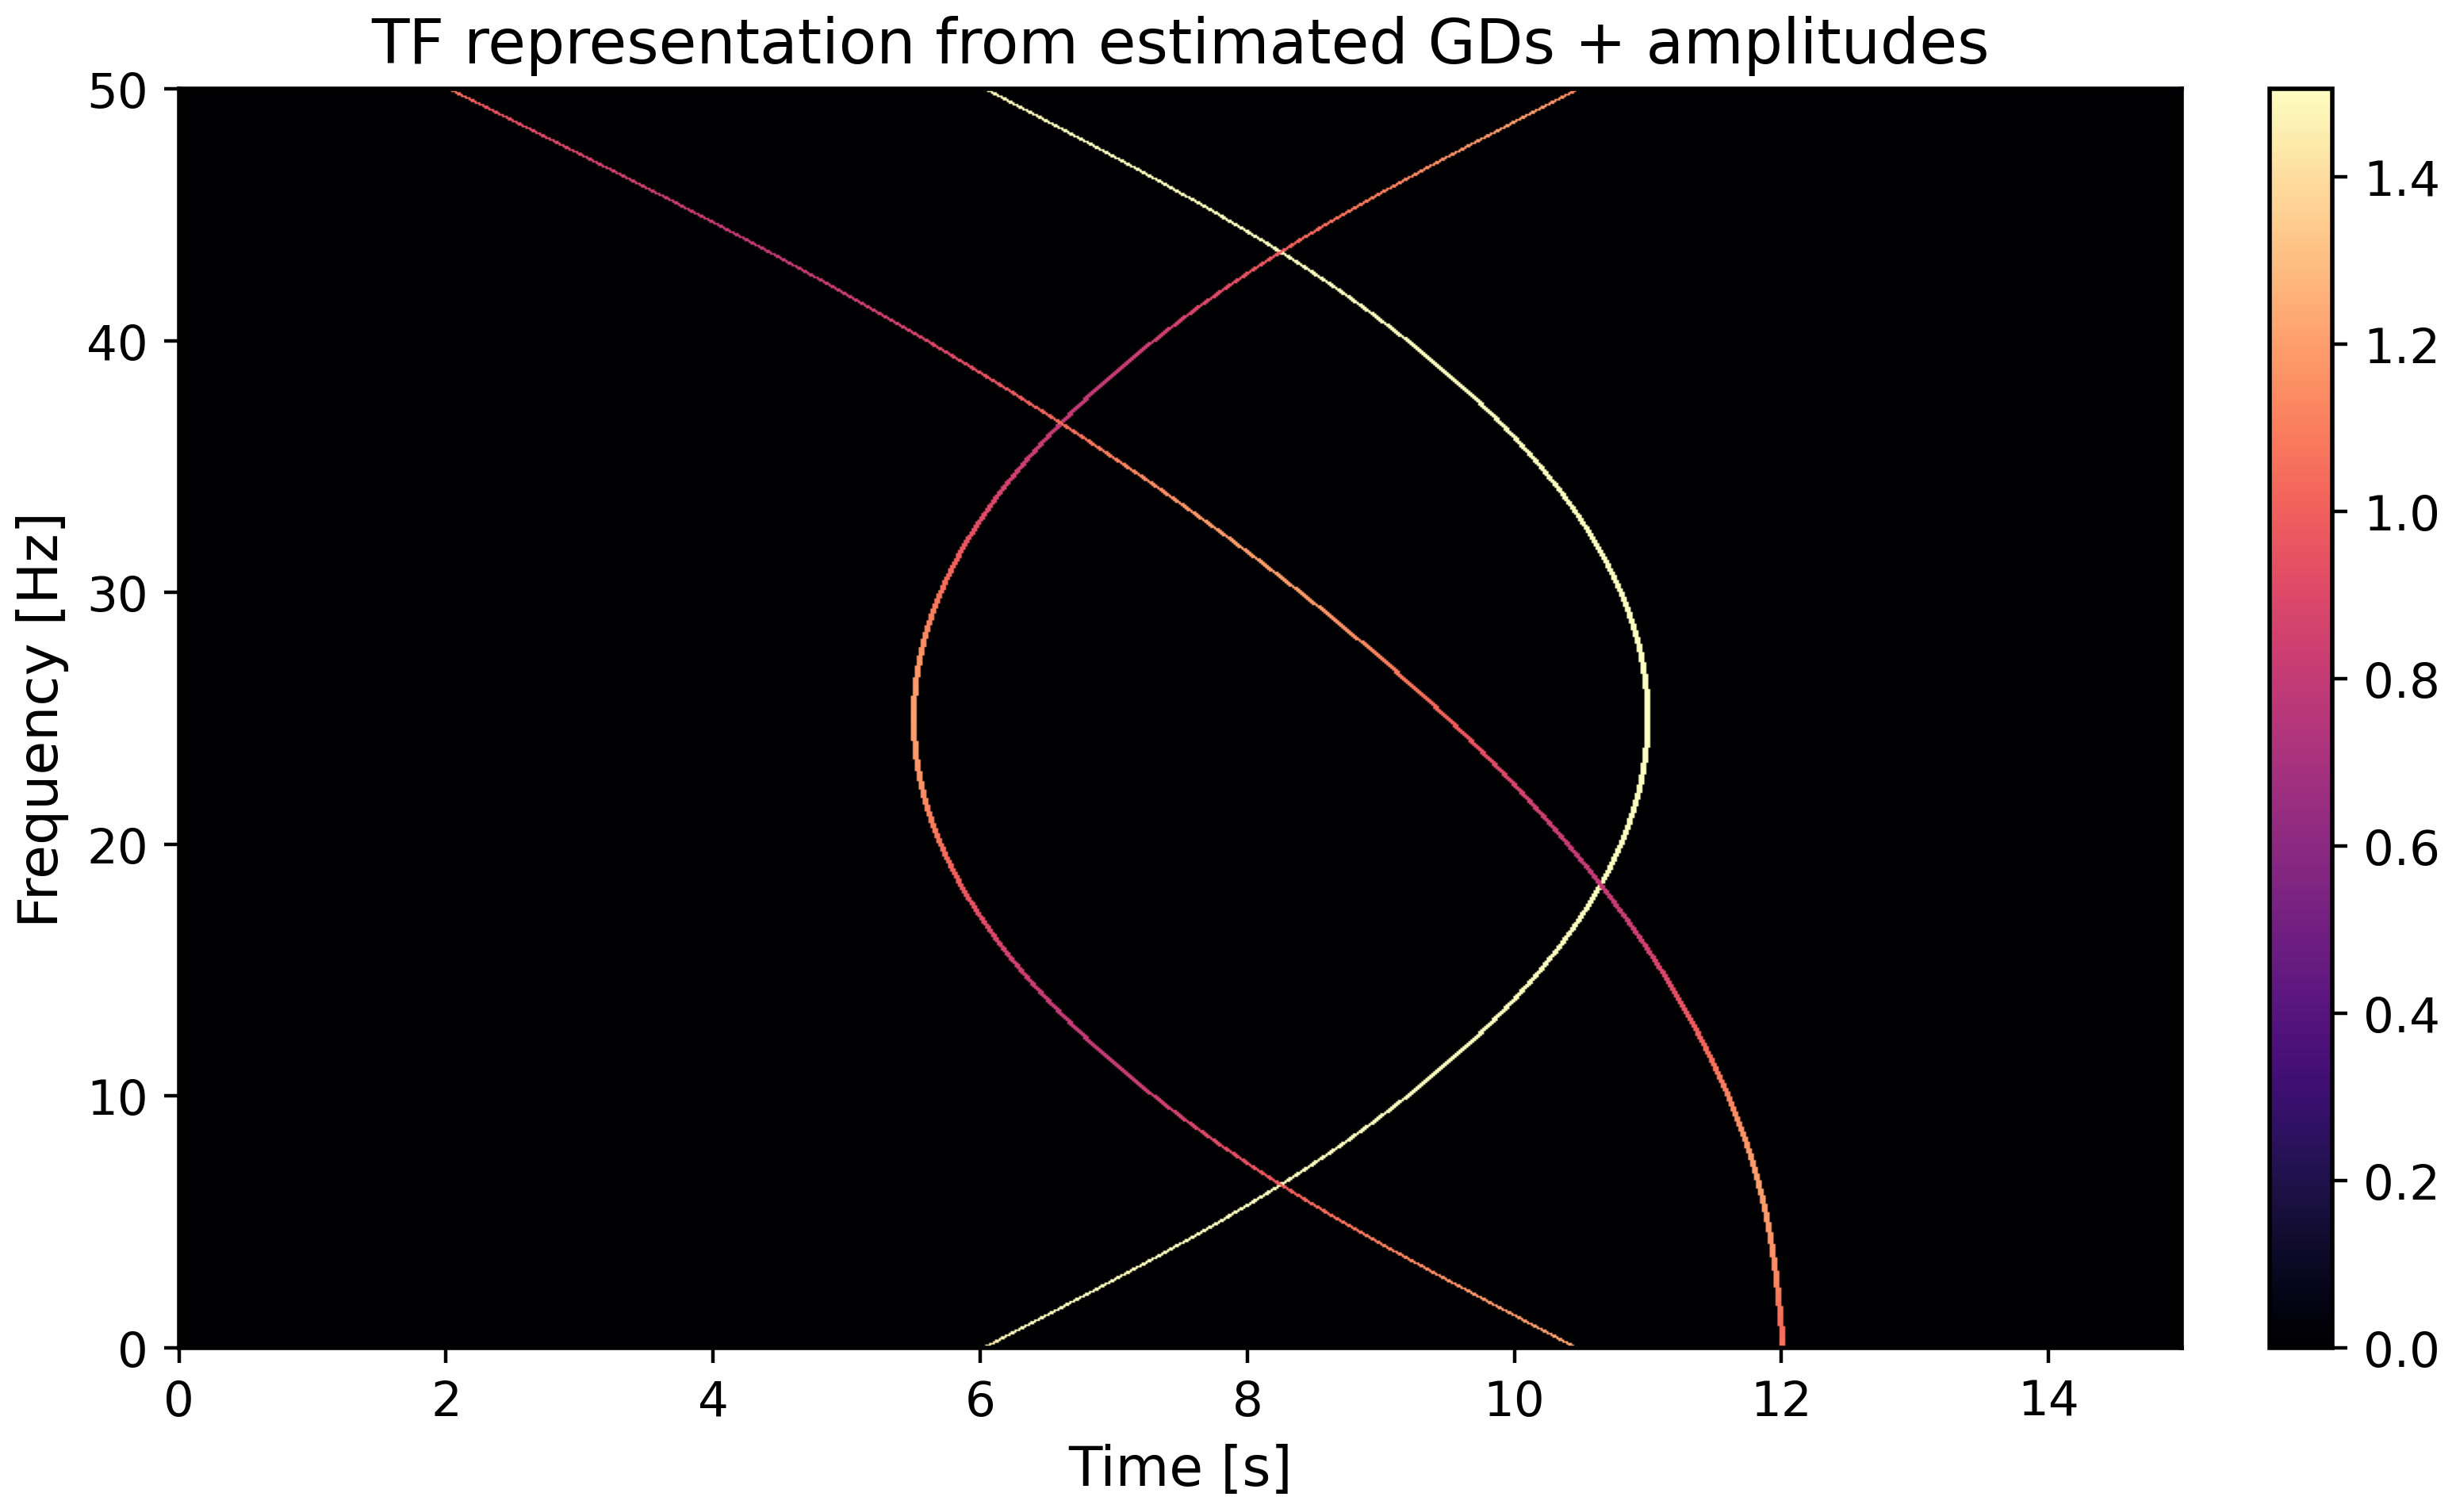

In [6]:
amp = np.abs(modes_freq)
ASpec, tbin = tf_spec_from_gd(est_gds, amp, time_range=(0.0, T), n_time_bins=1024)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    np.abs(ASpec),
    aspect="auto",
    origin="lower",
    extent=[tbin[0], tbin[-1], f[0], f[-1]],
    cmap="magma",
)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("TF representation from estimated GDs + amplitudes")
ax.set_xlim(0, T)
ax.set_ylim(0, fs / 2)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 6. Example 2 style — successive impulse extraction

Transient / impact responses are **special GDMs with nearly constant GD**
(TF ridges almost parallel to the frequency axis).  Railway-wheel fault
diagnosis in the paper uses this idea: initialise each mode at the **envelope
peak** of the current residual, run GDMD, subtract, and iterate until the
residual energy is small.

Set ``K`` and leave ``init_gd=None`` to enable that successive API.  Use a
**smaller** ``alpha`` / ``beta`` than in Example 1 when modes are sharply
impulsive (MATLAB Example 2 uses ``alpha=3e-7``, ``beta=1e-8``).


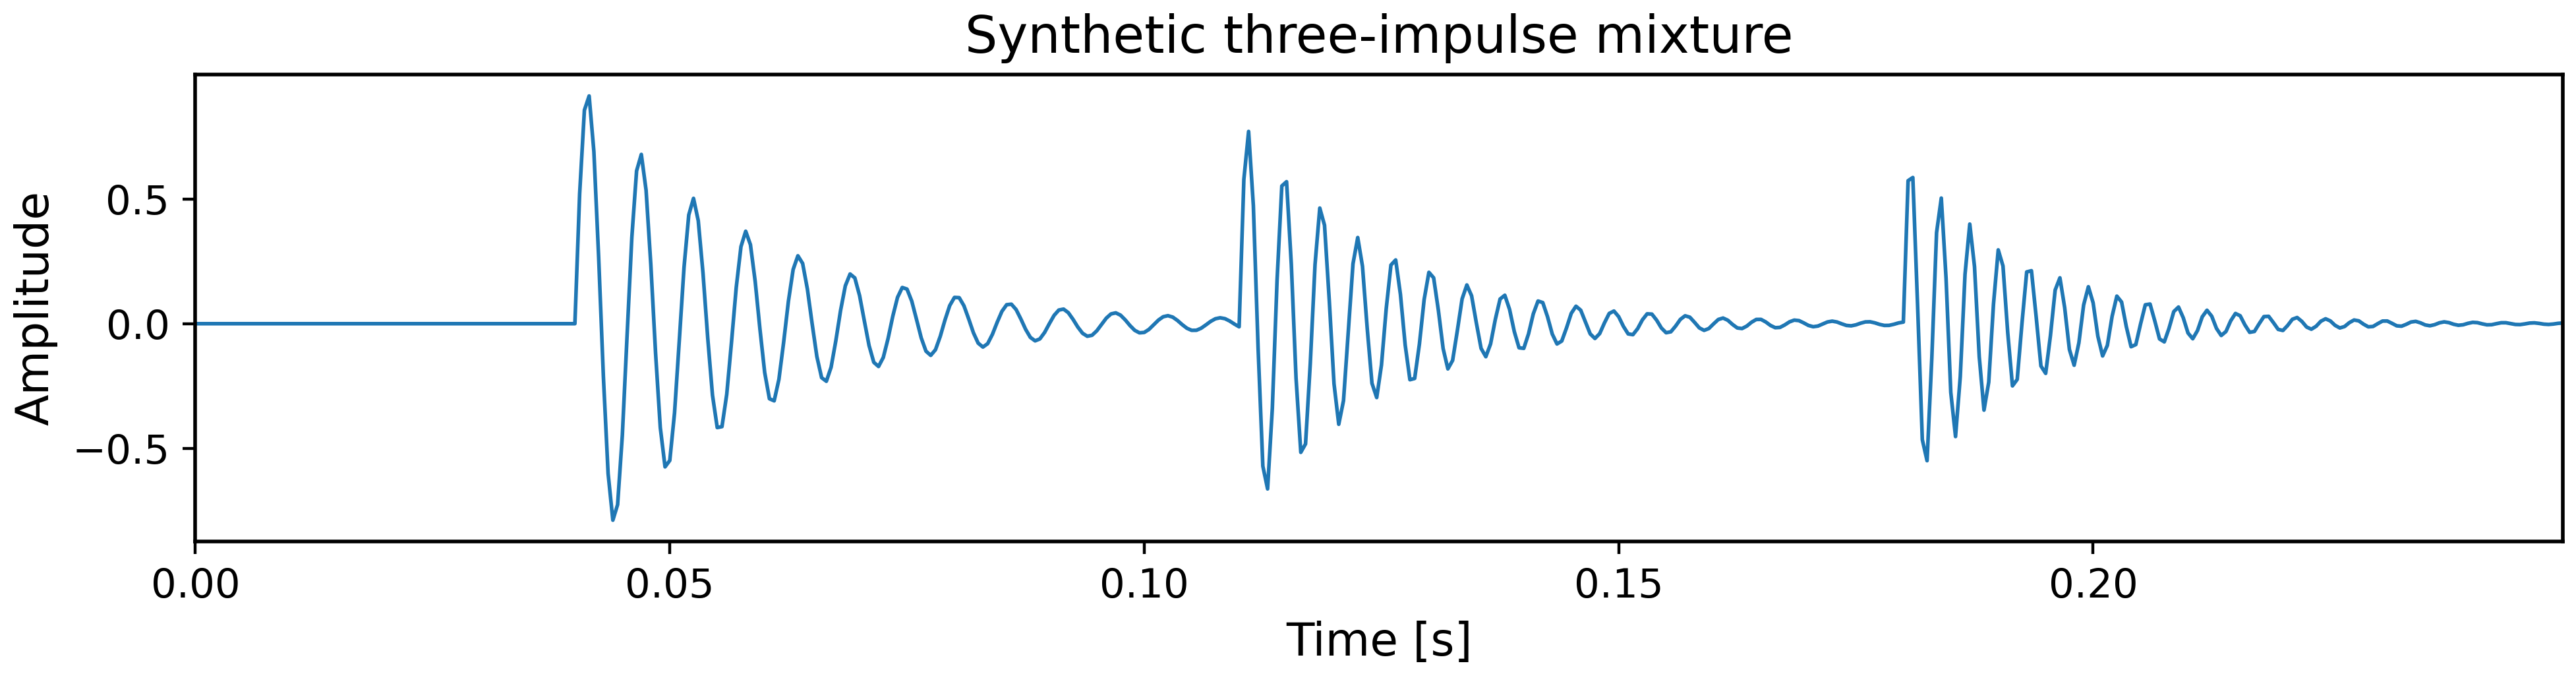

extracted modes: (3, 500)
reconstruction relative error: 0.808129155256081


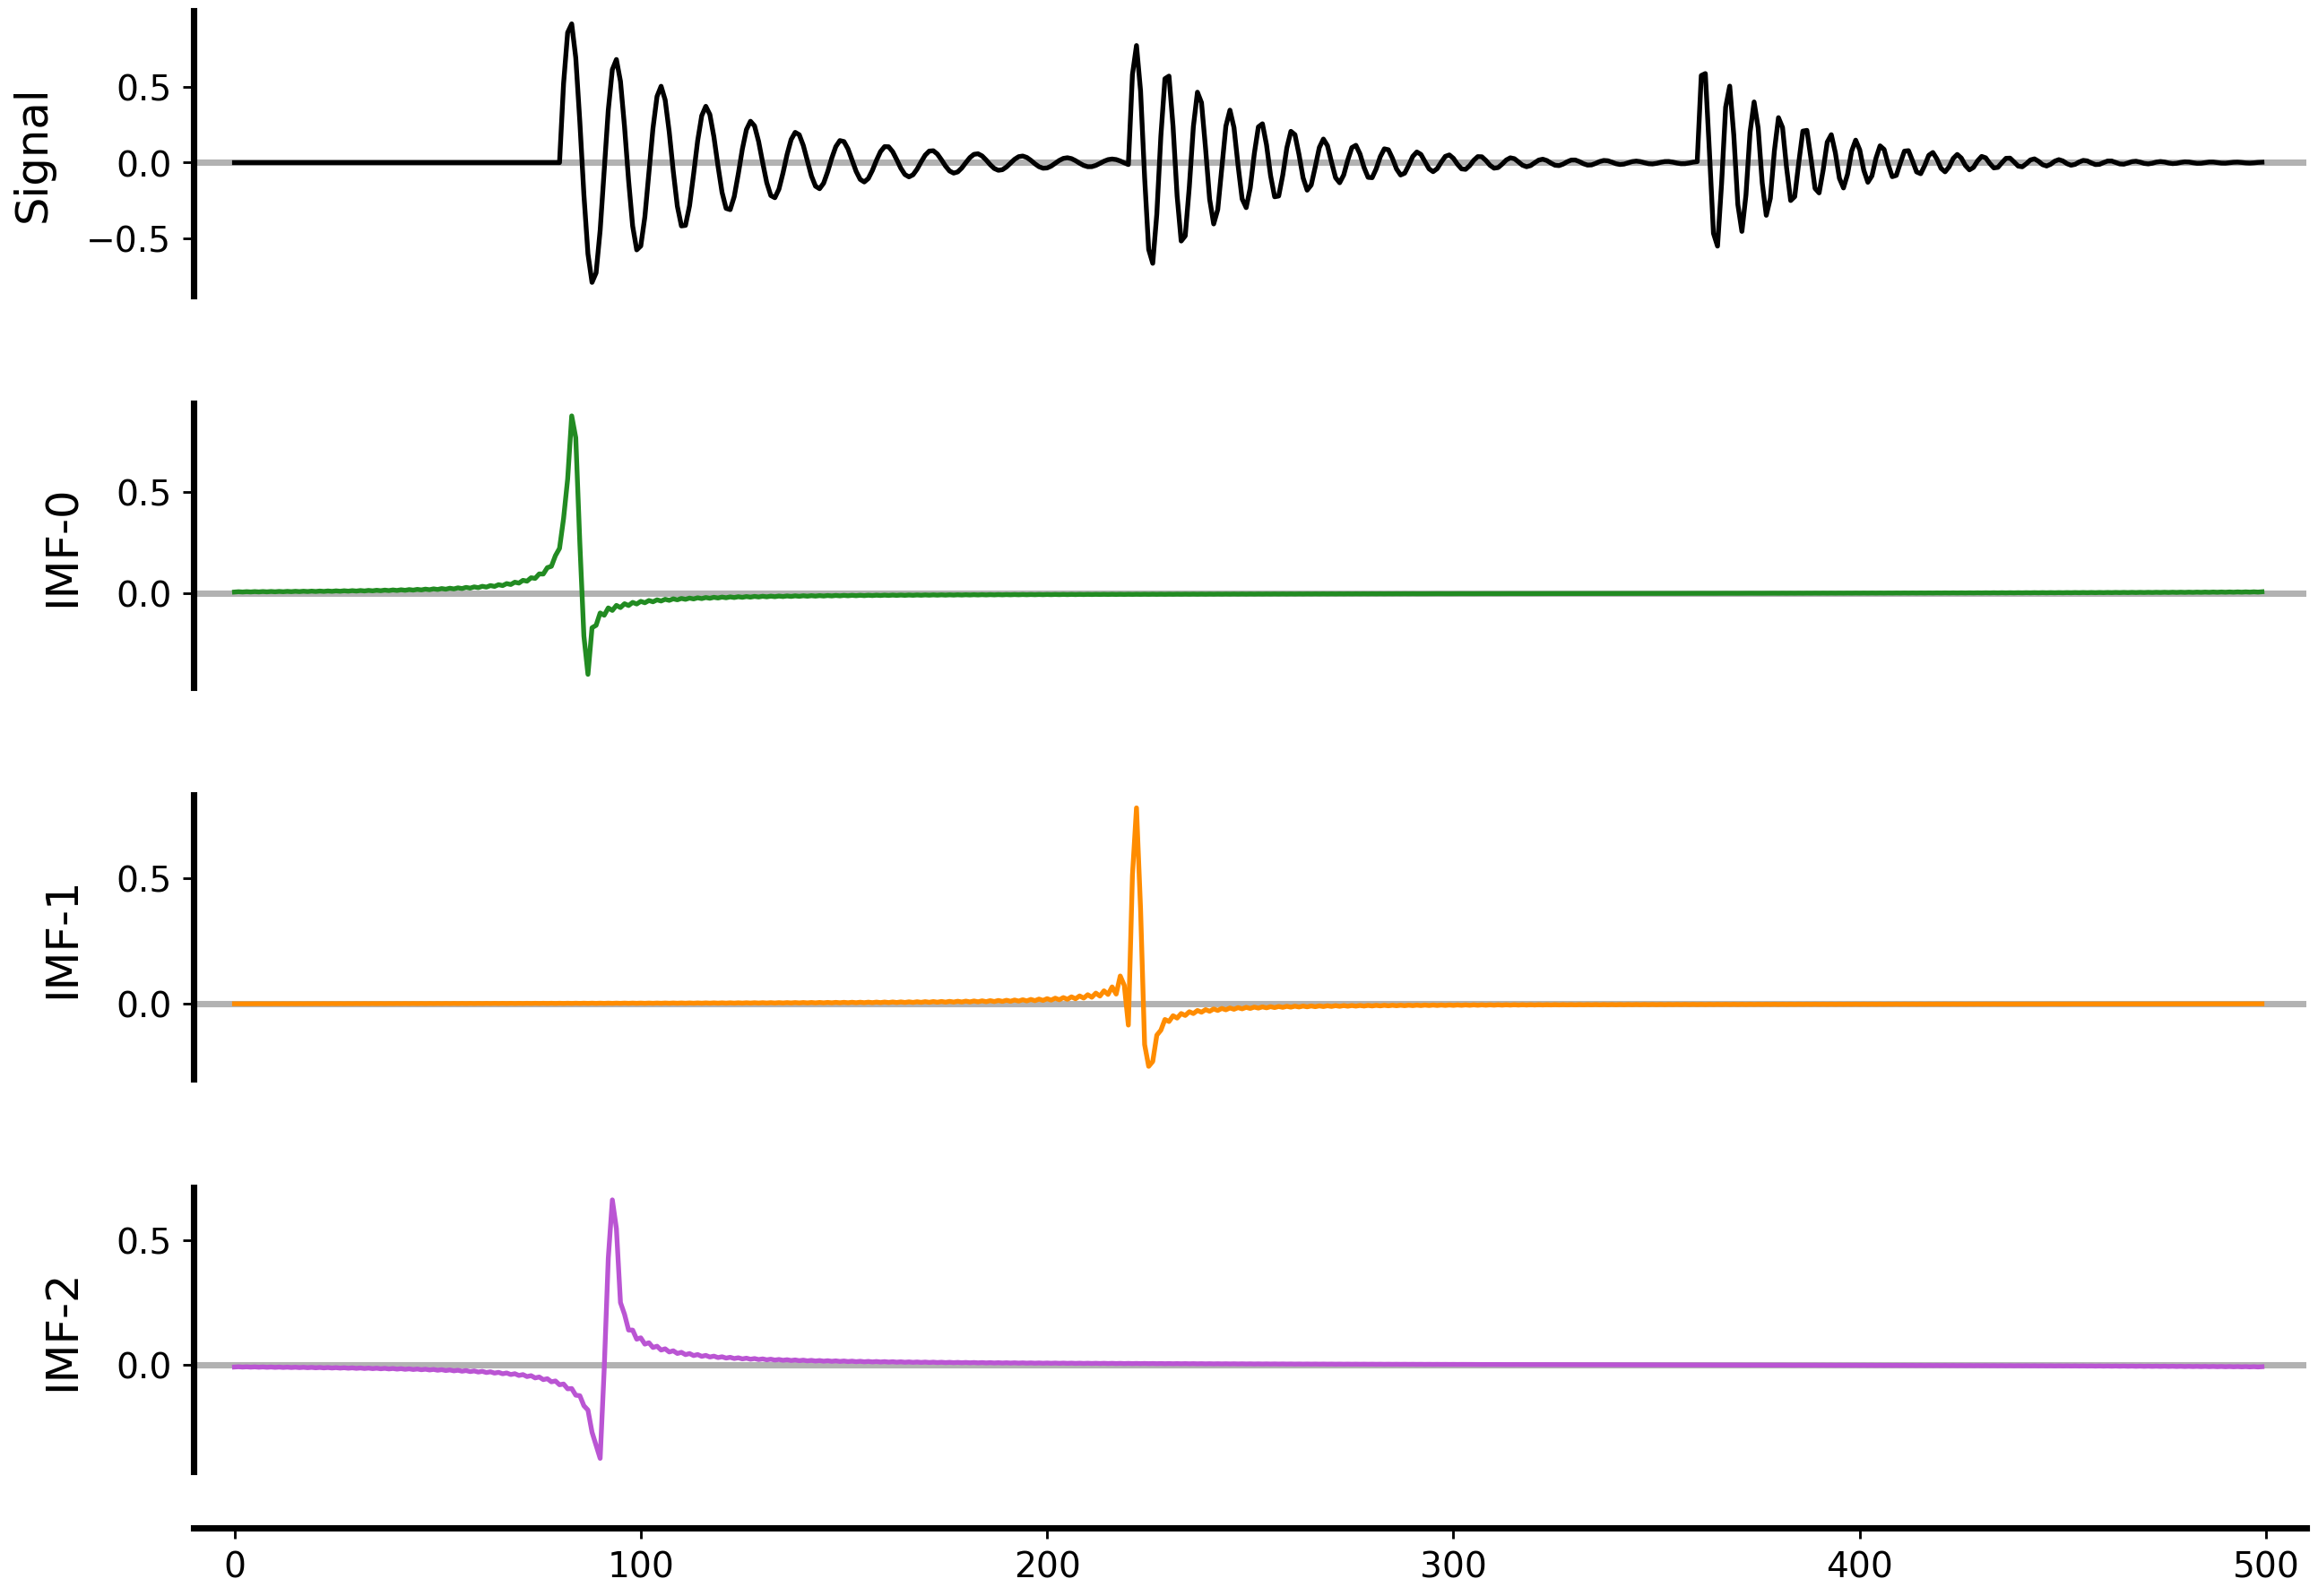

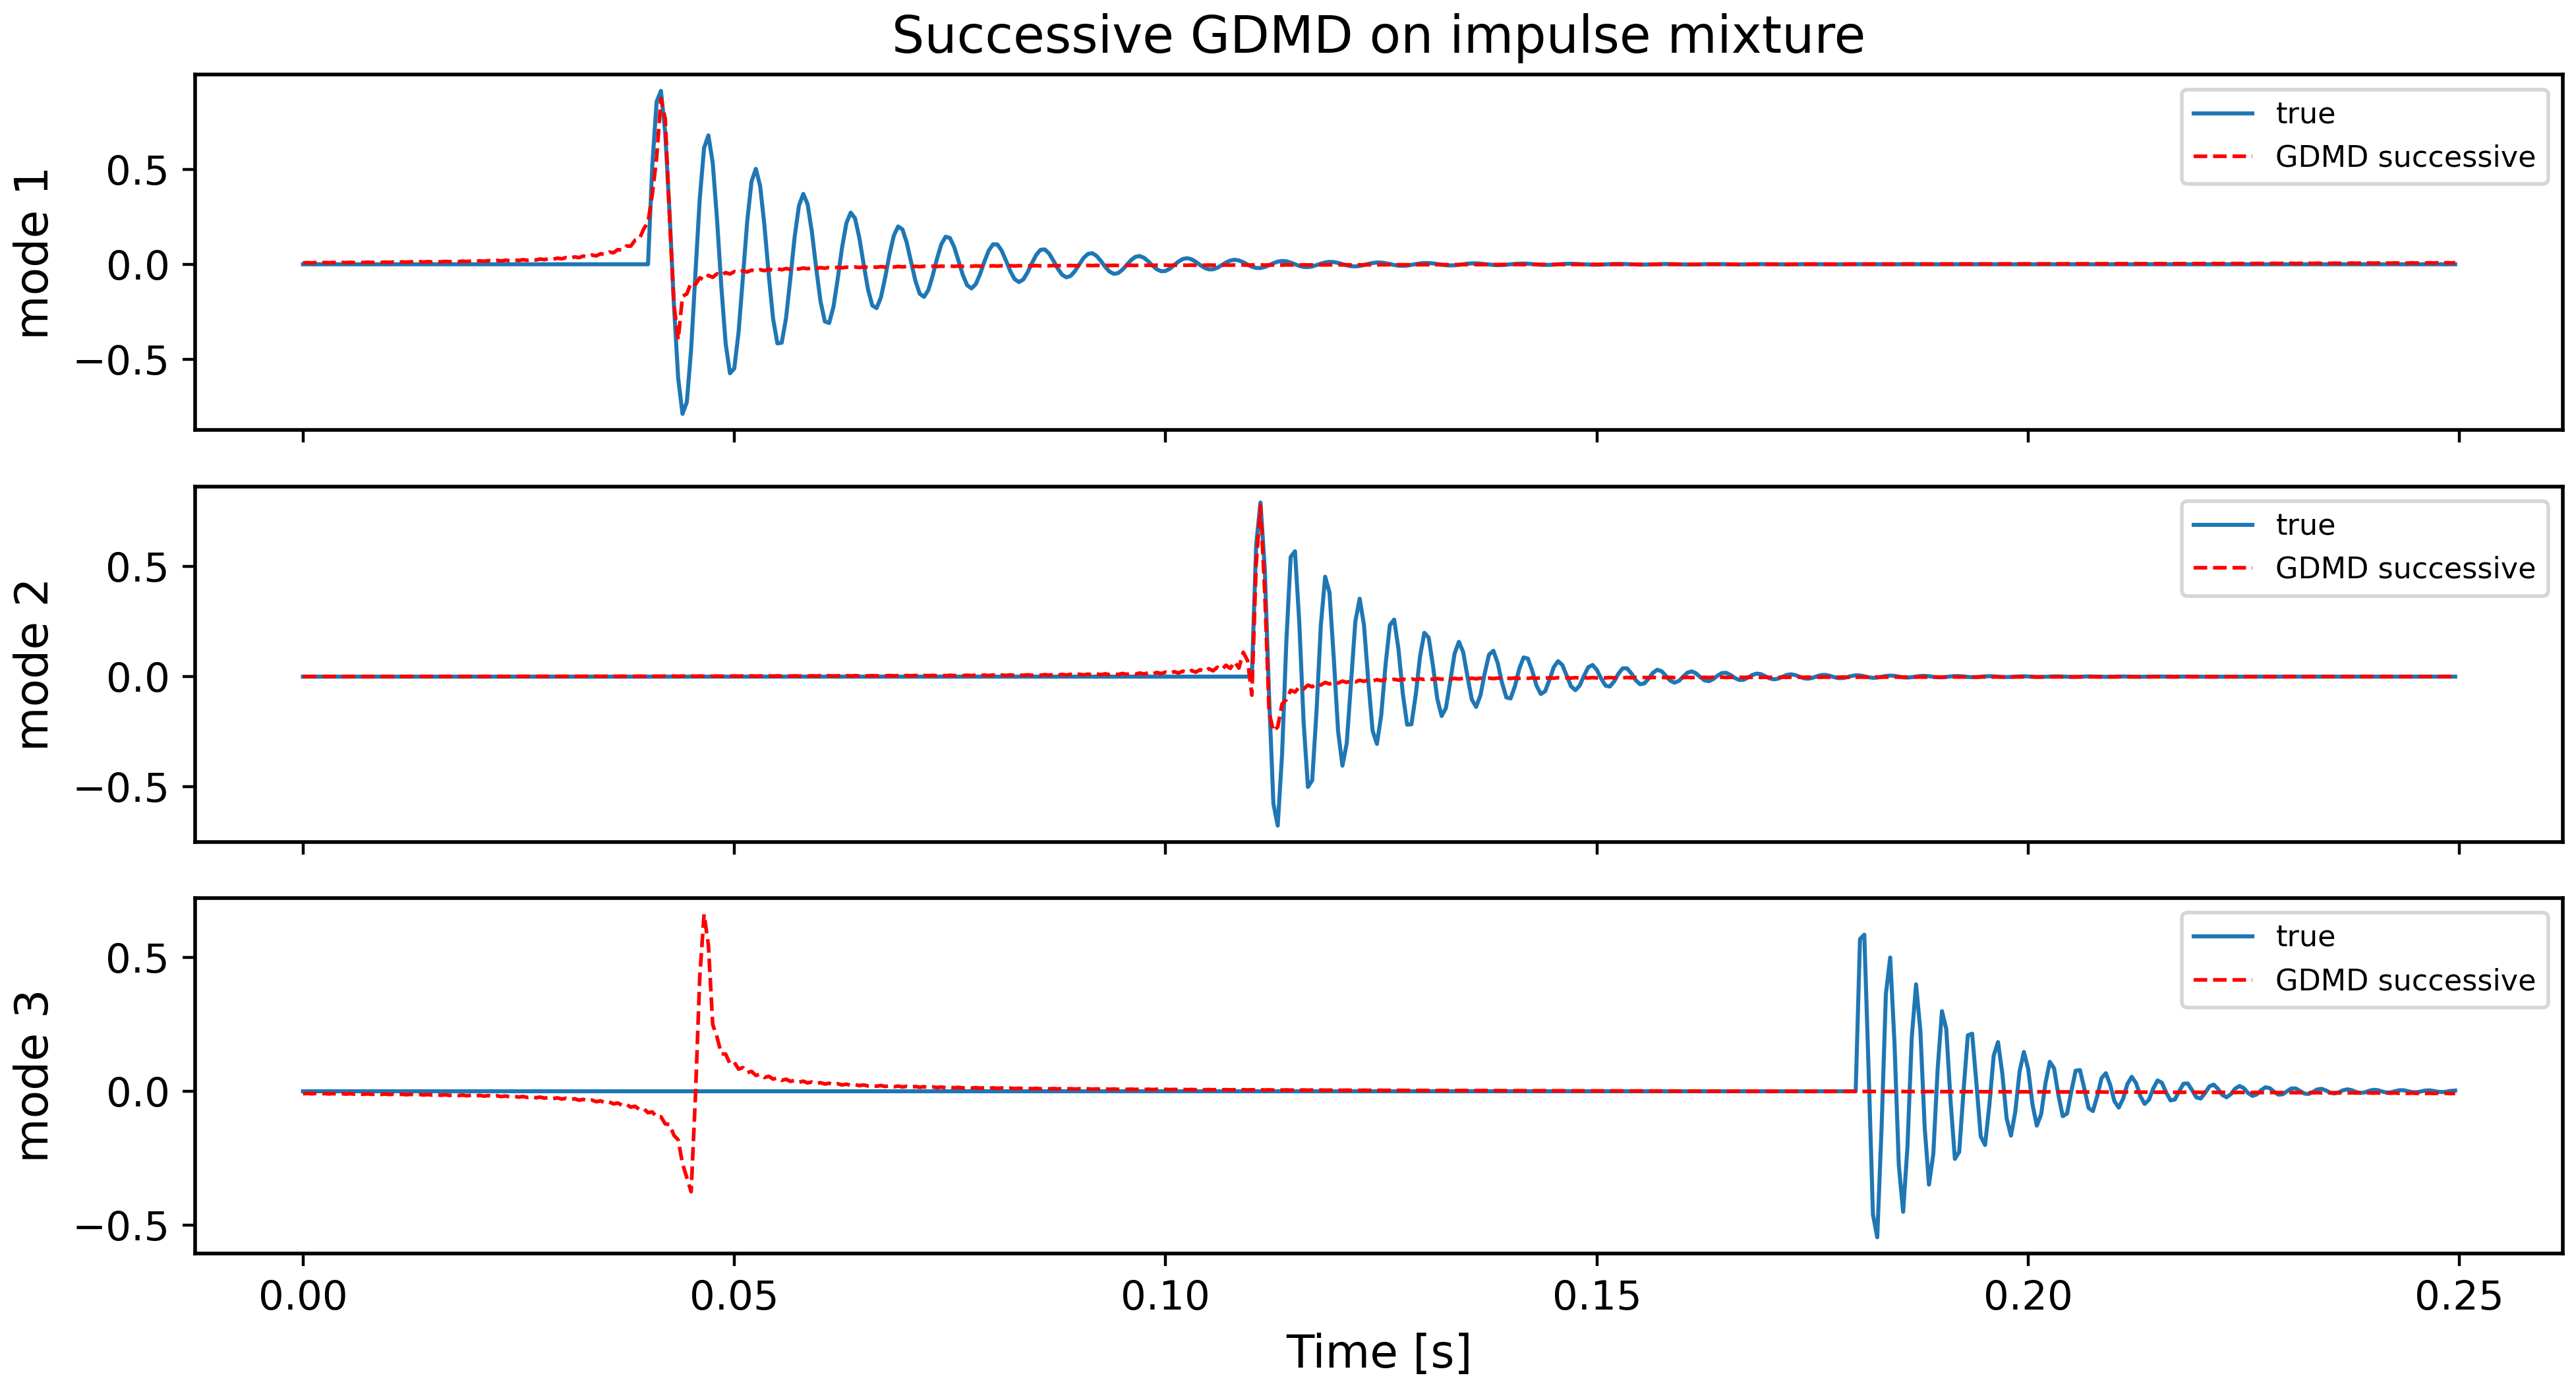

In [7]:
fs2 = 2000.0
t2 = np.arange(0.0, 0.25, 1.0 / fs2)


def impulse_atom(t0, f0, decay, amp=1.0):
    return (
        amp
        * np.exp(-decay * np.maximum(t2 - t0, 0.0))
        * np.sin(2 * np.pi * f0 * (t2 - t0))
        * (t2 >= t0)
    )


m1 = impulse_atom(0.04, 180.0, 55.0, amp=1.0)
m2 = impulse_atom(0.11, 260.0, 70.0, amp=0.85)
m3 = impulse_atom(0.18, 320.0, 80.0, amp=0.7)
impulse_sig = m1 + m2 + m3

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(t2, impulse_sig, color="C0", lw=1.0)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Synthetic three-impulse mixture")
ax.set_xlim(t2[0], t2[-1])
plt.tight_layout()
plt.show()

succ = GDMD(alpha=3e-7, beta=1e-8, tol=1e-7, max_iter=120, K=3)
imp_modes, imp_gds, _ = succ.fit_transform(impulse_sig, fs=fs2, return_all=True)

print(f"extracted modes: {imp_modes.shape}")
print(
    "reconstruction relative error:",
    np.linalg.norm(imp_modes.sum(0) - impulse_sig) / np.linalg.norm(impulse_sig),
)

plot_IMFs(impulse_sig, imp_modes, max_imfs=3)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
truth = [m1, m2, m3]
for k in range(3):
    # reorder estimated modes by envelope-peak time for a fair visual match
    axes[k].plot(t2, truth[k], color="C0", lw=1.1, label="true")
    axes[k].plot(t2, imp_modes[k], "r--", lw=1.0, label="GDMD successive")
    axes[k].set_ylabel(f"mode {k+1}")
    axes[k].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time [s]")
axes[0].set_title("Successive GDMD on impulse mixture")
plt.tight_layout()
plt.show()

## 7. Parameter cheat-sheet (PySDKit ↔ paper)

| PySDKit | Paper | Role |
|---|---|---|
| ``alpha`` | $\alpha$ | Mode / filter bandwidth. Smaller → smoother $G_i$, narrower effective band |
| ``beta`` | $\upsilon$ | GD-increment smoothness. Smaller → smoother $\tau_i(f)$ |
| ``tol`` | stopping rule in Fig. 4 | Relative change of recovered spectra (often $10^{-8}$) |
| ``max_iter`` | — | Cap on demodulation iterations (MATLAB default 300) |
| ``init_gd`` | $\tau_i^{(0)}(f)$ | Shape `(M, Nf)` in seconds — joint decomposition |
| ``K`` | $M$ for successive mode | Number of envelope-based extractions if ``init_gd`` is omitted |

**Initialisation tips (paper Sec. 3.2)**

- Nearly constant GD → peak of $|s(t)|$ or Hilbert envelope.
- Frequency-varying GD → TF ridge detector (SFFT/STFT) + optional RPRG for
  crossings, then ``curve_smooth(..., beta=1e-7)``.
- Choose $M$ from prior knowledge or a coarse TFA preview (as with VMD/VNCMD).

**Applications highlighted in the paper**

1. Separation of **crossed dispersive** synthetic modes and denoising.
2. **Railway wheel** impact-fault impulse extraction under strong noise.
3. Experimental **Lamb-wave** A0 / S0 separation with strong dispersion.

Further reading: ACMD / VNCMD papers by the same group explain the dual
chirp-side iteration that GDMD mirrors in the frequency domain.
